# Solar Flare Events — EDA

**About the data**

This dataset is a list of individual solar flares detected by the GOES X-ray sensors, 16,113 events from 2017-02-09 to 2026-06-10 (source: NOAA, via Hugging Face). A solar flare is a sudden burst of radiation from the Sun. Each flare is classified by its peak X-ray brightness into a letter class — A, B, C, M, X — where each letter is 10× brighter than the one before. The strong ones (M and X) matter to us because they can trigger radio blackouts, GPS errors, and geomagnetic storms.

Each row is one flare with its timing (`start_time`, `peak_time`, `end_time`), its peak brightness (`peak_flux_wm2`), and its class (`goes_class`, `goes_class_letter`). Full column descriptions are in `data/solar-flare-events/README.md`.

The group project predicts whether a geomagnetic storm happens, and flares are one of the upstream drivers we want as features. Before merging this data into the modeling table, this notebook cleans and understands it:

- check and handle missing values,
- make a few plots to see how flare duration, brightness, and class relate,
- decide which columns are useful as features, and engineer new ones where it helps.

The output is a cleaned flare dataset, ready to join with the other space-weather data by date.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df=pd.read_parquet('../../data/solar-flare-events/solar_flare_events.parquet')
df.head()


,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter
0,GOES-16,2017-02-09 00:41:00,2017-02-09 00:50:00,3.711663e-07,B3.7,2017-02-09 00:56:00,B
1,GOES-16,2017-02-09 01:30:00,2017-02-09 01:40:00,4.310535e-07,B4.3,2017-02-09 01:42:00,B
2,GOES-16,2017-02-09 01:45:00,2017-02-09 01:51:00,1.694939e-06,C1.6,2017-02-09 01:55:00,C
3,GOES-16,2017-02-09 02:31:00,2017-02-09 02:40:00,3.234027e-07,B3.2,2017-02-09 02:48:00,B
4,GOES-16,2017-02-09 02:55:00,2017-02-09 02:59:00,3.839661e-07,B3.8,NaT,B


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16113 entries, 0 to 16112
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   satellite          16113 non-null  string        
 1   start_time         16113 non-null  datetime64[us]
 2   peak_time          16087 non-null  datetime64[us]
 3   peak_flux_wm2      16087 non-null  float64       
 4   goes_class         16087 non-null  string        
 5   end_time           13971 non-null  datetime64[us]
 6   goes_class_letter  16087 non-null  string        
dtypes: datetime64[us](3), float64(1), string(3)
memory usage: 1.0 MB


In [90]:
df.describe()

,start_time,peak_time,peak_flux_wm2,end_time
count,16113,16087,1.608700e+04,13971
mean,2022-06-14 13:09:43.198659,2022-06-14 05:58:05.329769,6.000592e-06,2022-06-15 01:24:04.539403
min,2017-02-09 00:41:00,2017-02-09 00:50:00,9.748320e-08,2017-02-09 00:56:00
25%,2021-08-27 07:10:00,2021-08-27 00:47:00,7.210172e-07,2021-08-26 18:52:30
50%,2022-12-16 04:03:00,2022-12-15 22:18:00,2.330065e-06,2022-12-14 22:16:00
75%,2024-02-24 08:03:00,2024-02-24 02:30:00,5.000198e-06,2024-02-22 09:10:30
max,2026-06-10 08:08:00,2026-06-10 09:09:00,1.464082e-03,2026-06-10 03:36:00
std,NaN,NaN,2.677224e-05,NaN


In [91]:
print(f'Rows missing both peak_time and peak_flux_wm2: {len(df.query('peak_time.isnull() and peak_flux_wm2.isnull()'))}')

Rows missing both peak_time and peak_flux_wm2: 26


In [92]:
print(f"Rows missing peak_time but not peak_flux_wm2: {len(df.query('peak_time.isnull() and not peak_flux_wm2.isnull()'))}")
print(f"Rows missing peak_flux_wm2 but not peak_time: {len(df.query('not peak_time.isnull() and peak_flux_wm2.isnull()'))}")

Rows missing peak_time but not peak_flux_wm2: 0
Rows missing peak_flux_wm2 but not peak_time: 0


In [93]:
df.query('peak_time.isnull() and peak_flux_wm2.isnull()')

,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter
131,GOES-16,2017-03-04 05:30:00,NaT,NaN,<NA>,NaT,<NA>
267,GOES-16,2017-04-03 05:16:00,NaT,NaN,<NA>,NaT,<NA>
1205,GOES-16,2017-08-31 05:28:00,NaT,NaN,<NA>,NaT,<NA>
1415,GOES-16,2017-09-26 04:59:00,NaT,NaN,<NA>,NaT,<NA>
4120,GOES-16,2021-09-04 04:17:00,NaT,NaN,<NA>,NaT,<NA>
5662,GOES-16,2022-03-22 04:07:00,NaT,NaN,<NA>,NaT,<NA>
7098,GOES-16,2022-08-30 04:44:00,NaT,NaN,<NA>,NaT,<NA>
7238,GOES-16,2022-09-12 04:12:00,NaT,NaN,<NA>,NaT,<NA>
9085,GOES-16,2023-04-13 04:41:00,NaT,NaN,<NA>,NaT,<NA>
9267,GOES-16,2023-05-03 12:05:00,NaT,NaN,<NA>,NaT,<NA>


We know almost nothing about these events except their start time, so the missing values can't be inferred. Dropping the corresponding rows.

In [94]:
df=df.drop(index=df[df.peak_time.isnull() & df.peak_flux_wm2.isnull()].index)
df.info()


<class 'pandas.DataFrame'>
Index: 16087 entries, 0 to 16112
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   satellite          16087 non-null  string        
 1   start_time         16087 non-null  datetime64[us]
 2   peak_time          16087 non-null  datetime64[us]
 3   peak_flux_wm2      16087 non-null  float64       
 4   goes_class         16087 non-null  string        
 5   end_time           13971 non-null  datetime64[us]
 6   goes_class_letter  16087 non-null  string        
dtypes: datetime64[us](3), float64(1), string(3)
memory usage: 1.2 MB


In [95]:
# Checking which categories of events are missing their end time
df[df.end_time.isnull()]['goes_class_letter'].value_counts()

goes_class_letter
C    1315
B     642
M     158
X       1
Name: count, dtype: int64[pyarrow]

In [96]:
percents=((df[df.end_time.isnull()]['goes_class_letter'].value_counts().values)/len(df)*100).round(2)
print("Percent of missing end time by class")
for c, p in zip(df[df.end_time.isnull()]['goes_class_letter'].value_counts().index, percents):
    print(f"{c}: {p}%")

Percent of missing end time by class
C: 8.17%
B: 3.99%
M: 0.98%
X: 0.01%


In [97]:
null_end_time=(df.end_time.isnull())
df[null_end_time]

,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter
4,GOES-16,2017-02-09 02:55:00,2017-02-09 02:59:00,3.839661e-07,B3.8,NaT,B
15,GOES-16,2017-02-09 10:53:00,2017-02-09 11:00:00,1.166238e-07,B1.1,NaT,B
17,GOES-16,2017-02-09 11:52:00,2017-02-09 12:04:00,2.097050e-07,B2.0,NaT,B
28,GOES-16,2017-02-19 08:58:00,2017-02-19 09:06:00,4.473251e-07,B4.4,NaT,B
60,GOES-16,2017-02-22 17:20:00,2017-02-22 17:27:00,1.595764e-07,B1.5,NaT,B
...,...,...,...,...,...,...,...
16065,GOES-16,2025-04-01 06:25:00,2025-04-01 06:35:00,4.762585e-06,C4.7,NaT,C
16073,GOES-16,2025-04-01 20:45:00,2025-04-01 21:00:00,5.220541e-06,C5.2,NaT,C
16075,GOES-16,2025-04-01 22:00:00,2025-04-01 22:08:00,3.569627e-06,C3.5,NaT,C
16077,GOES-16,2025-04-02 01:15:00,2025-04-02 01:26:00,2.308811e-06,C2.3,NaT,C


In [98]:
df['duration_minutes'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60
df


,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter,duration_minutes
0,GOES-16,2017-02-09 00:41:00,2017-02-09 00:50:00,3.711663e-07,B3.7,2017-02-09 00:56:00,B,15.0
1,GOES-16,2017-02-09 01:30:00,2017-02-09 01:40:00,4.310535e-07,B4.3,2017-02-09 01:42:00,B,12.0
2,GOES-16,2017-02-09 01:45:00,2017-02-09 01:51:00,1.694939e-06,C1.6,2017-02-09 01:55:00,C,10.0
3,GOES-16,2017-02-09 02:31:00,2017-02-09 02:40:00,3.234027e-07,B3.2,2017-02-09 02:48:00,B,17.0
4,GOES-16,2017-02-09 02:55:00,2017-02-09 02:59:00,3.839661e-07,B3.8,NaT,B,NaN
...,...,...,...,...,...,...,...,...
16108,GOES-16,2025-04-06 15:46:00,2025-04-06 15:53:00,2.960594e-06,C2.9,2025-04-06 16:05:00,C,19.0
16109,GOES-16,2025-04-06 17:41:00,2025-04-06 17:44:00,2.088433e-06,C2.0,2025-04-06 17:47:00,C,6.0
16110,GOES-16,2025-04-06 19:47:00,2025-04-06 19:57:00,2.385995e-06,C2.3,2025-04-06 20:06:00,C,19.0
16111,GOES-18,2026-06-10 01:01:00,2026-06-10 09:09:00,9.800000e-04,C2.6,2026-06-10 00:01:00,C,-60.0


In [99]:
negative_duration=df.query('duration_minutes<0')
negative_duration

,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter,duration_minutes
16111,GOES-18,2026-06-10 01:01:00,2026-06-10 09:09:00,0.00098,C2.6,2026-06-10 00:01:00,C,-60.0
16112,GOES-18,2026-06-10 08:08:00,2026-06-10 03:03:00,0.00055,C1.0,2026-06-10 03:36:00,C,-272.0


In [100]:
df.drop(negative_duration.index, inplace=True)

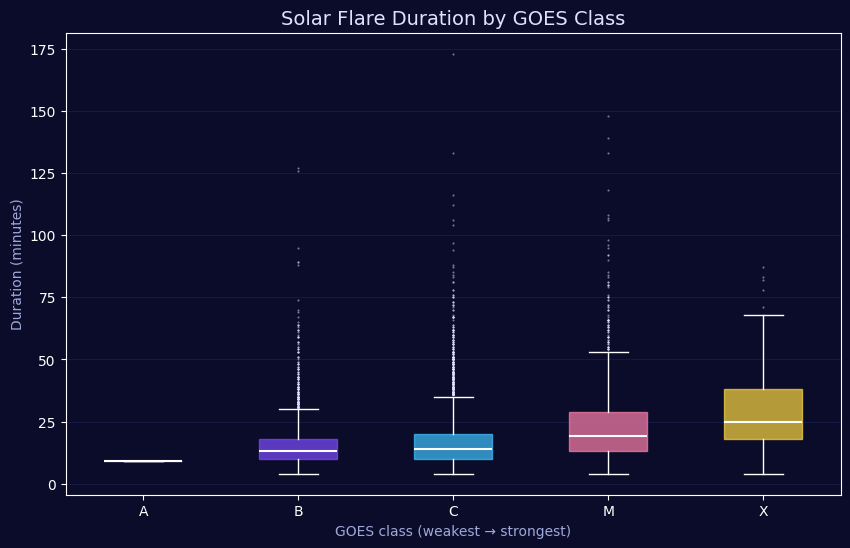

In [101]:
# Keep only rows with a known end time and class, compute duration in minutes,
# and drop the 2 bad rows where end_time is earlier than start_time.
flare_order = ['A', 'B', 'C', 'M', 'X']
plot_df = df.dropna(subset=['end_time', 'goes_class_letter']).copy()
plot_df['duration_minutes'] = (
    (plot_df['end_time'] - plot_df['start_time']).dt.total_seconds() / 60
)
plot_df = plot_df.query('duration_minutes >= 0')

# Group durations by flare class in ladder order (A weakest -> X strongest),
# skipping classes with no data.
classes = [c for c in flare_order if c in plot_df['goes_class_letter'].values]
durations_by_class = [
    plot_df.loc[plot_df['goes_class_letter'] == c, 'duration_minutes']
    for c in classes
]

# Draw a box plot of flare duration per class with a dark cosmic style
plt.style.use('dark_background')
cosmic_colors = ['#b388ff', '#7c4dff', '#40c4ff', '#ff80ab', '#ffd740']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0b0c2a')
ax.set_facecolor('#0b0c2a')

boxes = ax.boxplot(
    durations_by_class,
    tick_labels=classes,
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 1.5},
    flierprops={'marker': '.', 'markersize': 3, 'markerfacecolor': '#e0e0ff',
                'markeredgecolor': 'none', 'alpha': 0.5},
)
for patch, color in zip(boxes['boxes'], cosmic_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor(color)

ax.set_title('Solar Flare Duration by GOES Class', color='#e0e0ff', fontsize=14)
ax.set_xlabel('GOES class (weakest → strongest)', color='#9fa8da')
ax.set_ylabel('Duration (minutes)', color='#9fa8da')
ax.grid(axis='y', color='#3949ab', alpha=0.3, linewidth=0.5)
fig.savefig('outputs/flare_duration_by_class_boxplot.png', dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

Looking at the flare duration by class (intensity of the solar flare event), we can see that more impactful flares (M, X) tend to last slightly longer than frequent, non-dangerous ones (A, B, C). Each class, except A, has a significant number of outliers which may indicate that classification does not depend on solar flare duration alone. 

# Imputing strategy for end time and duration
I am going to impute the missing duration with the median (not the mean, due to outliers in each class) of events in the same intensity category (A, B, C, M, or X), since a flare's duration is correlated with its intensity. The fraction of missing end times is fairly small, so median imputation won't degrade data quality much.
I will also add a binary `end_time_imputed` column to give the model a signal for which rows were filled, then use the imputed duration to reconstruct the `end_time` column.

In [102]:
mean_duration_by_class=df.groupby('goes_class_letter')['duration_minutes'].median()
mean_duration_by_class

goes_class_letter
A     9.0
B    13.0
C    14.0
M    19.0
X    25.0
Name: duration_minutes, dtype: float64

In [103]:
# Flag which rows are about to be imputed
df['end_time_imputed'] = df['end_time'].isna().astype(int)

# Fill duration_minutes with class median
df['duration_minutes'] = df['duration_minutes'].fillna(
    df.groupby('goes_class_letter')['duration_minutes'].transform('median')
)

# Reconstruct end_time from start_time + filled duration
df['end_time'] = df['end_time'].fillna(
    df['start_time'] + pd.to_timedelta(df['duration_minutes'], unit='m')
)

In [104]:
df.isnull().sum()

satellite            0
start_time           0
peak_time            0
peak_flux_wm2        0
goes_class           0
end_time             0
goes_class_letter    0
duration_minutes     0
end_time_imputed     0
dtype: int64

Next: look at the overall distribution of duration, a histogram of duration by class, and the relationship between `peak_flux_wm2` and duration.

In [105]:
# Shared cosmic style: one color per flare class, reused in the next cells
plt.style.use('dark_background')
SPACE_BG = '#0b0c2a'
CLASS_COLORS = {'A': '#b388ff', 'B': '#7c4dff', 'C': '#40c4ff',
                'M': '#ff80ab', 'X': '#ffd740'}

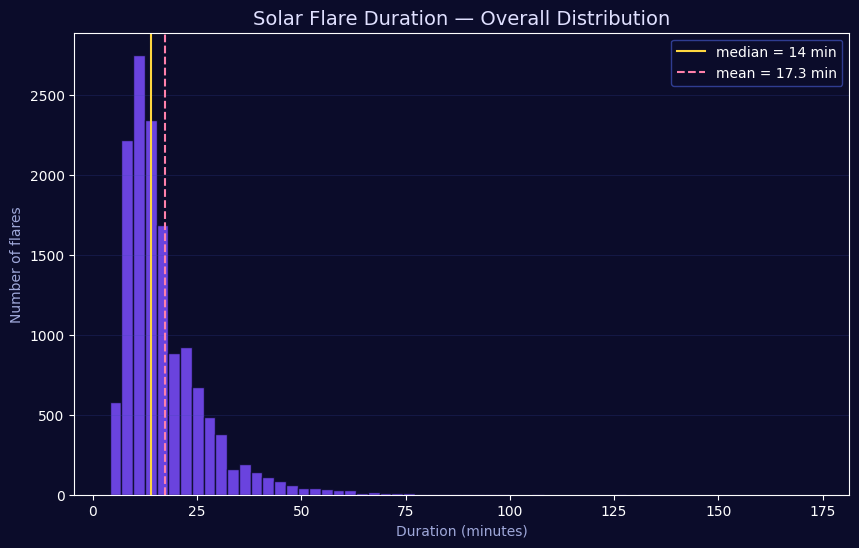

In [106]:
# Histogram of flare duration across all classes, with median and mean markers
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(SPACE_BG)
ax.set_facecolor(SPACE_BG)

ax.hist(plot_df['duration_minutes'], bins=60, color='#7c4dff',
        edgecolor='#0b0c2a', alpha=0.85)
ax.axvline(plot_df['duration_minutes'].median(), color='#ffd740',
           linewidth=1.5, label=f"median = {plot_df['duration_minutes'].median():.0f} min")
ax.axvline(plot_df['duration_minutes'].mean(), color='#ff80ab',
           linewidth=1.5, linestyle='--',
           label=f"mean = {plot_df['duration_minutes'].mean():.1f} min")

ax.set_title('Solar Flare Duration — Overall Distribution', color='#e0e0ff', fontsize=14)
ax.set_xlabel('Duration (minutes)', color='#9fa8da')
ax.set_ylabel('Number of flares', color='#9fa8da')
ax.legend(facecolor=SPACE_BG, edgecolor='#3949ab')
ax.grid(axis='y', color='#3949ab', alpha=0.3, linewidth=0.5)
fig.savefig('outputs/flare_duration_distribution.png', dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

The overall distribution of duration in minutes shows that most events are within ~10 to ~20 minute range, with a visible tail of outliers going past that threshold. The distribution is right-skewed, and the mean is greater than median due to those outliers.

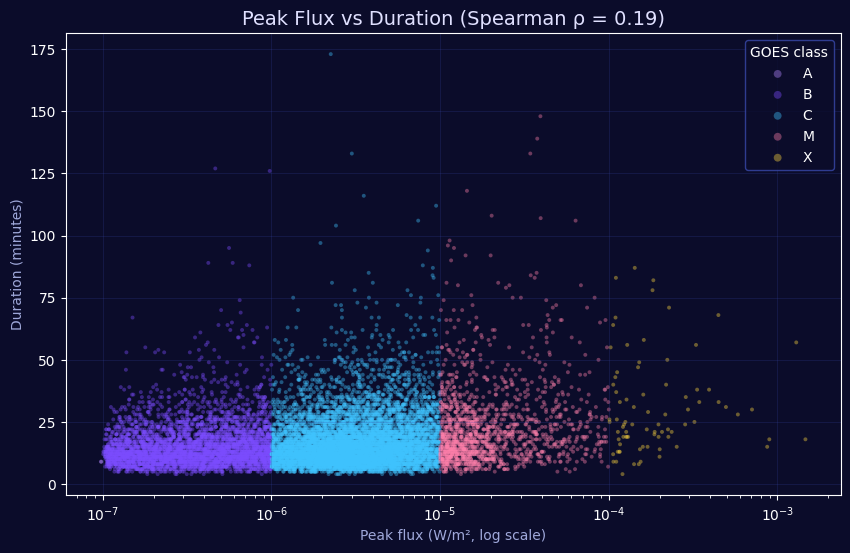

In [107]:
# Scatter of peak flux vs duration with class hue. Flux spans several orders of
# magnitude (B ~1e-7 to X ~1e-4 W/m^2), so the x-axis is log-scaled and the
# correlation is computed with Spearman (rank-based, robust to skew).
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(SPACE_BG)
ax.set_facecolor(SPACE_BG)

for cls in ['A', 'B', 'C', 'M', 'X']:
    subset = plot_df[plot_df['goes_class_letter'] == cls]
    ax.scatter(subset['peak_flux_wm2'], subset['duration_minutes'],
               s=8, alpha=0.4, color=CLASS_COLORS[cls], label=cls,
               edgecolors='none')

rho, _ = spearmanr(plot_df['peak_flux_wm2'], plot_df['duration_minutes'])
ax.set_xscale('log')
ax.set_title(f'Peak Flux vs Duration (Spearman ρ = {rho:.2f})',
             color='#e0e0ff', fontsize=14)
ax.set_xlabel('Peak flux (W/m², log scale)', color='#9fa8da')
ax.set_ylabel('Duration (minutes)', color='#9fa8da')
ax.legend(facecolor=SPACE_BG, edgecolor='#3949ab', title='GOES class',
          markerscale=2)
ax.grid(color='#3949ab', alpha=0.3, linewidth=0.5)
fig.savefig('outputs/peak_flux_vs_duration_scatter.png', dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

I checked how peak flux relates to duration using Spearman correlation (better than Pearson in this case because it captures not just linear correlation which may be heavily skewed by outliers here). There is a weak positive relationship — brighter flares tend to last somewhat longer — but the spread is large, so flux alone does not determine duration. The scatter plots of peak flux by class do not overlap, which connfirms that the class is primarily determined by the flux.

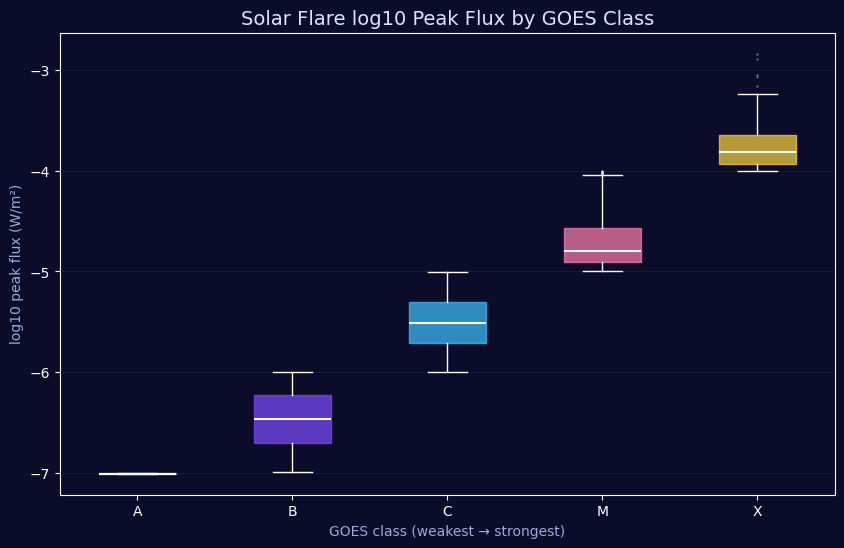

In [108]:
# Work on a log10 scale for flux: it spans orders of magnitude and the A->X
# class ladder is itself defined in powers of ten.
df['log_peak_flux'] = np.log10(df['peak_flux_wm2'])


# Box plot of log10 peak flux per class to see flux spread and outliers
# (dots beyond the whiskers) within each intensity category.
classes = [c for c in flare_order if c in df['goes_class_letter'].values]
flux_by_class = [df.loc[df['goes_class_letter'] == c, 'log_peak_flux'] for c in classes]

plt.style.use('dark_background')
cosmic_colors = ['#b388ff', '#7c4dff', '#40c4ff', '#ff80ab', '#ffd740']


fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0b0c2a')
ax.set_facecolor('#0b0c2a')

boxes = ax.boxplot(
    flux_by_class,
    tick_labels=classes,
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 1.5},
    flierprops={'marker': '.', 'markersize': 3, 'markerfacecolor': '#e0e0ff',
                'markeredgecolor': 'none', 'alpha': 0.5},
)
for patch, color in zip(boxes['boxes'], cosmic_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor(color)

ax.set_title('Solar Flare log10 Peak Flux by GOES Class', color='#e0e0ff', fontsize=14)
ax.set_xlabel('GOES class (weakest → strongest)', color='#9fa8da')
ax.set_ylabel('log10 peak flux (W/m²)', color='#9fa8da')
ax.grid(axis='y', color='#3949ab', alpha=0.3, linewidth=0.5)
fig.savefig('outputs/peak_flux_by_class_boxplot.png', dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

This plot confirms that GOES class is heavily correlated with flux values.

# Looking at outliers
Checking duration and flux for extreme values: first overall (beyond 3 standard deviations), then within each class using the IQR rule.

In [109]:
mean_duration=df.duration_minutes.mean()
std=df.duration_minutes.std()
outliers_by_duration=df[(df.duration_minutes>mean_duration+3*std) | (df.duration_minutes<mean_duration-3*std)]
outliers_by_duration

,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter,duration_minutes,end_time_imputed,log_peak_flux
79,GOES-16,2017-02-24 16:57:00,2017-02-24 17:34:00,4.584236e-07,B4.5,2017-02-24 17:51:00,B,54.0,0,-6.338733
239,GOES-16,2017-04-01 19:21:00,2017-04-01 19:56:00,5.773486e-06,C5.7,2017-04-01 20:13:00,C,52.0,0,-5.238562
374,GOES-16,2017-04-17 02:11:00,2017-04-17 02:47:00,3.117804e-06,C3.1,2017-04-17 03:10:00,C,59.0,0,-5.506151
392,GOES-16,2017-04-18 19:15:00,2017-04-18 20:10:00,8.453525e-06,C8.4,2017-04-18 20:49:00,C,94.0,0,-5.072962
472,GOES-16,2017-05-27 17:59:00,2017-05-27 18:30:00,1.404303e-06,C1.4,2017-05-27 19:02:00,C,63.0,0,-5.852539
...,...,...,...,...,...,...,...,...,...,...
15804,GOES-16,2025-02-25 11:20:00,2025-02-25 11:59:00,3.636333e-05,M3.6,2025-02-25 12:43:00,M,83.0,0,-4.439336
15887,GOES-16,2025-03-08 17:38:00,2025-03-08 18:25:00,3.990003e-06,C3.9,2025-03-08 18:59:00,C,81.0,0,-5.399027
15893,GOES-16,2025-03-10 20:00:00,2025-03-10 20:32:00,2.082075e-06,C2.0,2025-03-10 20:56:00,C,56.0,0,-5.681504
15959,GOES-16,2025-03-20 16:49:00,2025-03-20 17:10:00,4.424483e-06,C4.4,2025-03-20 17:49:00,C,60.0,0,-5.354138


In [110]:
outliers_by_duration['goes_class_letter'].value_counts()

goes_class_letter
C    148
M    107
B     43
X     15
Name: count, dtype: int64[pyarrow]

In [111]:
outliers_by_duration.describe()

,start_time,peak_time,peak_flux_wm2,end_time,duration_minutes,end_time_imputed,log_peak_flux
count,313,313,3.130000e+02,313,313.000000,313.0,313.000000
mean,2022-10-01 08:28:14.568690,2022-10-01 09:00:32.587859,2.473851e-05,2022-10-01 09:32:35.846645,64.354633,0.0,-5.187058
min,2017-02-24 16:57:00,2017-02-24 17:34:00,1.381099e-07,2017-02-24 17:51:00,49.000000,0.0,-6.859775
25%,2022-01-16 04:56:00,2022-01-16 05:11:00,2.542789e-06,2022-01-16 05:47:00,53.000000,0.0,-5.594690
50%,2023-04-02 08:03:00,2023-04-02 08:26:00,6.693635e-06,2023-04-02 09:01:00,59.000000,0.0,-5.174338
75%,2024-03-13 23:24:00,2024-03-13 23:49:00,1.639867e-05,2024-03-14 00:15:00,70.000000,0.0,-4.785191
max,2025-03-29 21:19:00,2025-03-29 21:38:00,1.291589e-03,2025-03-29 22:08:00,173.000000,0.0,-2.888876
std,NaN,NaN,8.448320e-05,NaN,17.892273,0.0,0.695267


The dataset contains 313 solar flare events which duration is beyond 3 standard deviations from the global mean (there are no events with shorter durations). Most of them are class C and M, with the least number of X events, which confirms that duration alone does not determine how energy-intensive the event is

In [112]:
# Flag IQR outliers within each group: a value is an outlier if it sits below
# Q1 - 1.5*IQR or above Q3 + 1.5*IQR of its own flare class.
def flag_group_outliers(data, value_col, group_col):
    grouped = data.groupby(group_col)[value_col]
    q1 = grouped.transform(lambda s: s.quantile(0.25))
    q3 = grouped.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    return (data[value_col] < q1 - 1.5 * iqr) | (data[value_col] > q3 + 1.5 * iqr)

# Flag per-class outliers separately for duration and for log peak flux.
df['duration_outlier'] = flag_group_outliers(df, 'duration_minutes', 'goes_class_letter')
df['flux_outlier'] = flag_group_outliers(df, 'log_peak_flux', 'goes_class_letter')

# Per-class summary: event count, outliers of each kind, and their rate.
flare_order = ['A', 'B', 'C', 'M', 'X']
outlier_summary = df.groupby('goes_class_letter').agg(
    n_events=('peak_flux_wm2', 'size'),
    duration_outliers=('duration_outlier', 'sum'),
    flux_outliers=('flux_outlier', 'sum'),
).reindex([c for c in flare_order if c in df['goes_class_letter'].values])
outlier_summary['duration_outlier_pct'] = (
    outlier_summary['duration_outliers'] / outlier_summary['n_events'] * 100
).round(2)
outlier_summary['flux_outlier_pct'] = (
    outlier_summary['flux_outliers'] / outlier_summary['n_events'] * 100
).round(2)
outlier_summary

,n_events,duration_outliers,flux_outliers,duration_outlier_pct,flux_outlier_pct
goes_class_letter,,,,,
A,2,0,0,0.00,0.00
B,4780,309,0,6.46,0.00
C,9612,651,0,6.77,0.00
M,1609,107,21,6.65,1.31
X,82,6,5,7.32,6.10


The table containing the number of outliers in each class by duration and flux measurements. While we cannot really change the duration and flux, we should consider how to address class imbalance (very few events of X category, and those events are the most consequential for our life on Earth).

In [113]:
# only one unique satelite in the dataset despite documentation mentioning 2
df['satellite'].unique()

<ArrowStringArray>
['GOES-16']
Length: 1, dtype: string

# Features to include in the model

| feature | decision | reason |
|---------|----------|--------|
| peak_flux_wm2 | Keep | Peak X-ray brightness of the flare; the main measure of flare energy and what the GOES class is built from. |
| duration_minutes | Keep | How long the flare lasted (`end_time - start_time`); a longer flare can mean more energy released. |
| goes_class_letter | Keep | Flare intensity category (A/B/C/M/X); a clean, ordered summary of flare strength. |
| end_time_imputed | Keep (engineered) | Binary flag for rows where the duration/end time was filled with the class median, so the model knows which durations are estimated rather than measured. |
| log_peak_flux | Optional — future iteration (engineered) | log10 of peak flux. Flux spans several orders of magnitude, so a log scale might give a cleaner signal than the raw value. |
| duration_outlier | Optional — future iteration (engineered) | Binary flag for flares with an unusually long/short duration within their own class (IQR rule); might provide meaningful signal later. |
| flux_outlier | Optional — future iteration (engineered) | Binary flag for flares with an unusually high/low peak flux within their own class (IQR rule); might provide meaningful signal later. |

# EDA summary

**What I did**

- Loaded the GOES solar flare events dataset: 16,113 events, all from one satellite (GOES-16), spanning 2017-02-09 to 2026-06-10.
- Dropped 26 rows that were missing both `peak_time` and `peak_flux_wm2` — we knew almost nothing about these events (only their start time), so the values couldn't be inferred.
- Built a `duration_minutes` column from `end_time - start_time`, then dropped 2 bad rows where `end_time` came before `start_time` (negative duration).
- Handled missing end times: about 2,116 rows had no `end_time`. I filled the missing duration with the **median** duration of the same flare class (median, not mean, because each class has outliers), then rebuilt `end_time` from the filled duration. I added an `end_time_imputed` flag so the model can tell which rows were filled.
- Made plots to understand the data: duration by class (boxplot), overall duration distribution (histogram), peak flux vs duration (scatter), and log10 peak flux by class (boxplot).
- Checked for outliers two ways: globally (313 events more than 3 standard deviations above the mean duration) and within each class using the IQR rule, flagging them as `duration_outlier` and `flux_outlier`.
- Saved the cleaned data to `data/clean-data/solar-flare-events.parquet`.

**Insights**

- Stronger flares (M, X) tend to last a bit longer than weaker ones (A, B, C), but every class has many duration outliers — so duration alone does not decide the flare class.
- Peak flux and duration have only a weak positive relationship (Spearman ρ ≈ low): brighter flares last somewhat longer, but the spread is wide, so flux does not determine duration.
- GOES class is essentially determined by peak flux — the flux boxplots for each class barely overlap.
- There is a strong class imbalance: very few X events, even though those are the most consequential ones. We will need to address this during modeling.

In [114]:
df.to_parquet('../../data/clean-data/solar-flare-events.parquet')